Titanic Survival Prediction

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('titanic_dataset.csv')

In [5]:
df.head()

,survived,pclass,gender,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.tail( )

,survived,pclass,gender,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [7]:
df.shape

(891, 15)

In [8]:
df.columns

Index(['survived', 'pclass', 'gender', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(107)

In [10]:
df = df.drop_duplicates()


In [11]:
df.isnull().sum()

survived         0
pclass           0
gender           0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df= df.drop(['deck',], axis = 1)

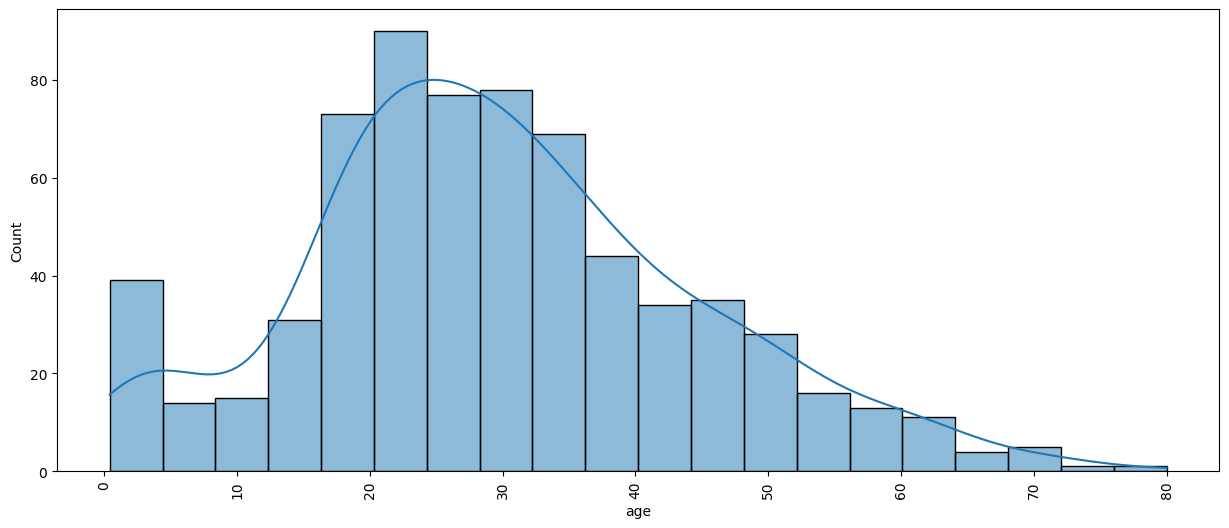

In [13]:
plt.figure(figsize=(15,6))
sns.histplot(df['age'], bins = 20, kde = True, palette='hls')
plt.xticks(rotation = 90)
plt.show()

In [14]:
median_levy = df['age'].dropna().astype(int).median()

In [15]:
df['age'] = df['age'].fillna(median_levy)

In [16]:
mode_value=df['embarked'].mode()[0]
df['embarked']=df['embarked'].fillna(mode_value)

In [17]:
mode_value=df['embark_town'].mode()[0]
df['embark_town']=df['embark_town'].fillna(mode_value)  

In [18]:
object_columns = df.select_dtypes(include=['object','bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['gender', 'embarked', 'class', 'who', 'adult_male', 'embark_town',
       'alive', 'alone'],
      dtype='object')

Numerical type columns:
Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


In [19]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype in ['object','bool']:
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [20]:
categorical, non_categorical, discrete, continuous = classify_features(df)


In [21]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: ['gender', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
Non-Categorical Features: []
Discrete Features: ['survived', 'pclass', 'sibsp', 'parch']
Continuous Features: ['age', 'fare']


Data Visualization

In [22]:
for i in discrete:
    print(i)
    print(df[i].unique())
    print()

survived
[0 1]

pclass
[3 1 2]

sibsp
[1 0 3 4 2 5 8]

parch
[0 1 2 5 3 4 6]



In [23]:
for i in discrete:
    print(df[i].value_counts())
    print()

survived
0    461
1    323
Name: count, dtype: int64

pclass
3    405
1    214
2    165
Name: count, dtype: int64

sibsp
0    517
1    201
2     27
4     18
3     14
5      5
8      2
Name: count, dtype: int64

parch
0    580
1    114
2     75
5      5
3      5
4      4
6      1
Name: count, dtype: int64



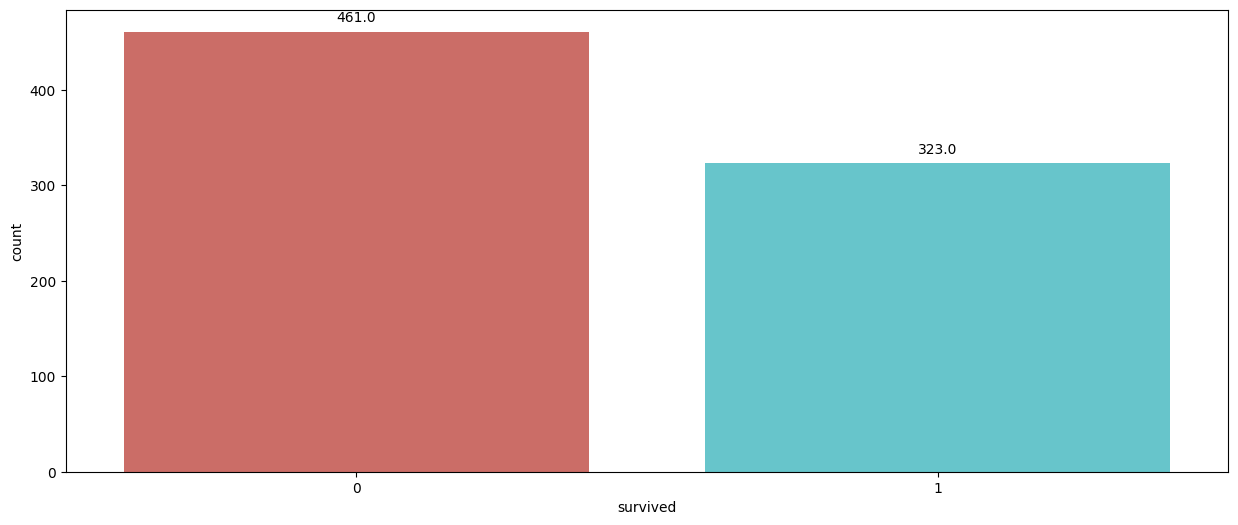

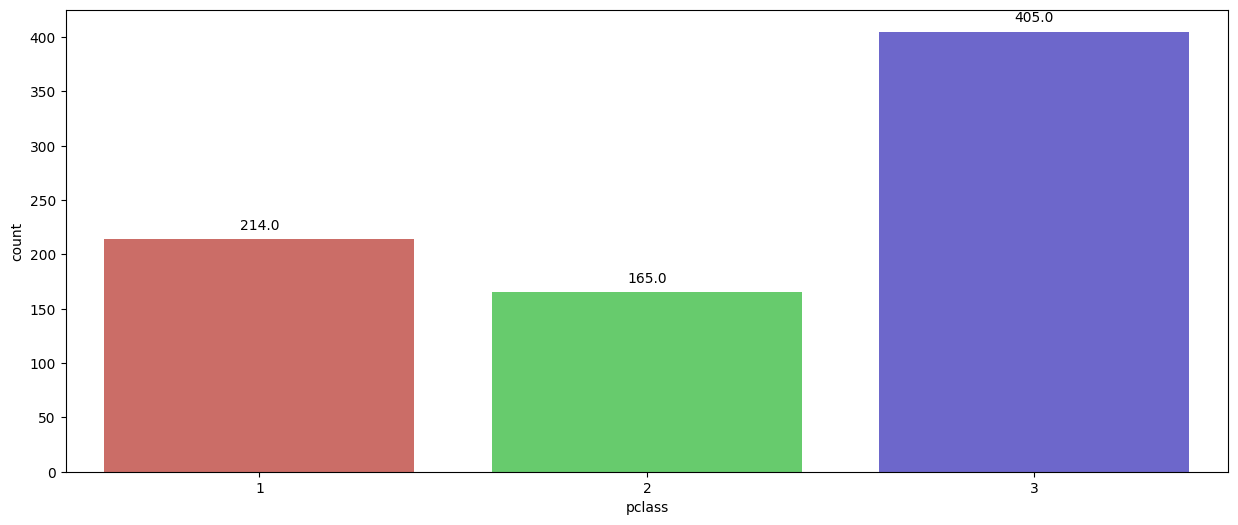

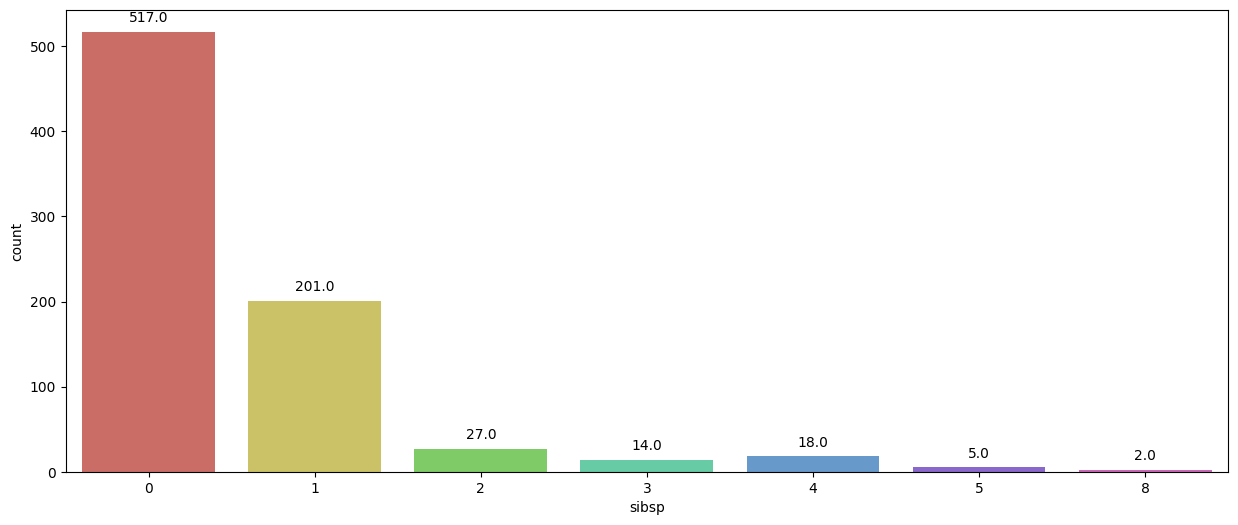

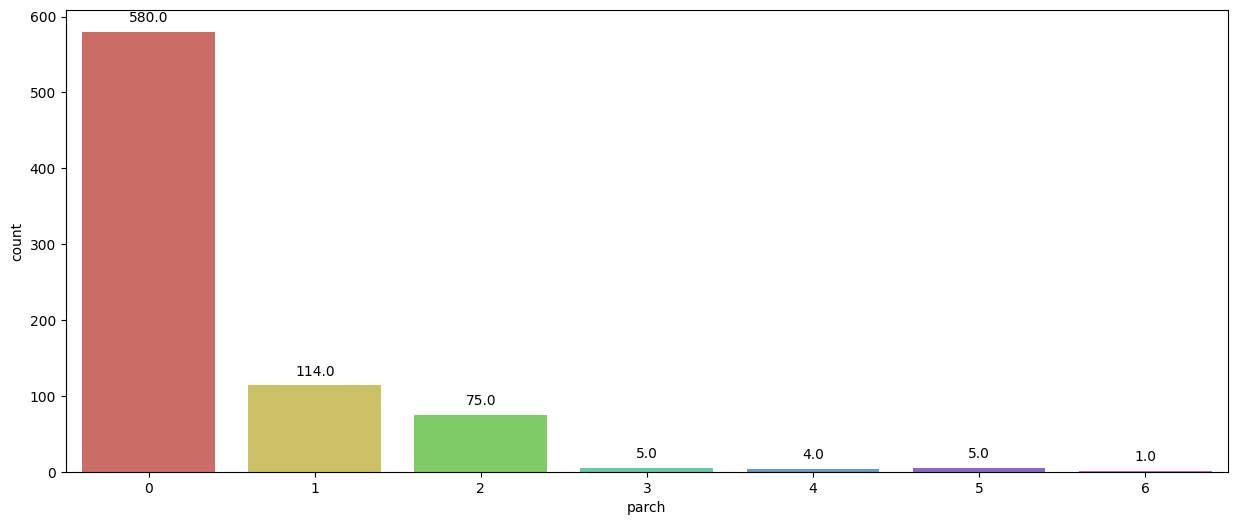

In [24]:
for i in discrete:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
    plt.show()

In [25]:
import plotly.express as px
import plotly.io as pio

for i in discrete:
    counts = df[i].value_counts()
    fig = px.pie(counts, values=counts.values, names=counts.index, title=f'Distribution of {i}')
    fig.show()

In [26]:
for i in categorical:
    print(i)
    print(df[i].unique())
    print()

gender
['male' 'female']

embarked
['S' 'C' 'Q']

class
['Third' 'First' 'Second']

who
['man' 'woman' 'child']

adult_male
[ True False]

embark_town
['Southampton' 'Cherbourg' 'Queenstown']

alive
['no' 'yes']

alone
[False  True]



In [27]:
for i in categorical:
    print(i)
    print(df[i].value_counts())
    print()

gender
gender
male      491
female    293
Name: count, dtype: int64

embarked
embarked
S    570
C    155
Q     59
Name: count, dtype: int64

class
class
Third     405
First     214
Second    165
Name: count, dtype: int64

who
who
man      451
woman    251
child     82
Name: count, dtype: int64

adult_male
adult_male
True     451
False    333
Name: count, dtype: int64

embark_town
embark_town
Southampton    570
Cherbourg      155
Queenstown      59
Name: count, dtype: int64

alive
alive
no     461
yes    323
Name: count, dtype: int64

alone
alone
True     446
False    338
Name: count, dtype: int64



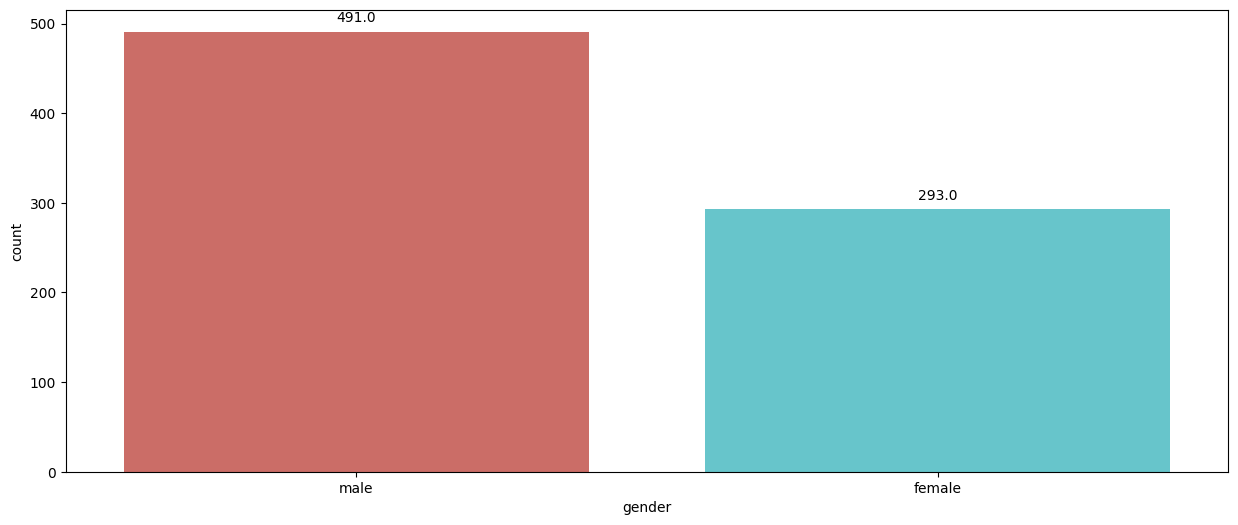

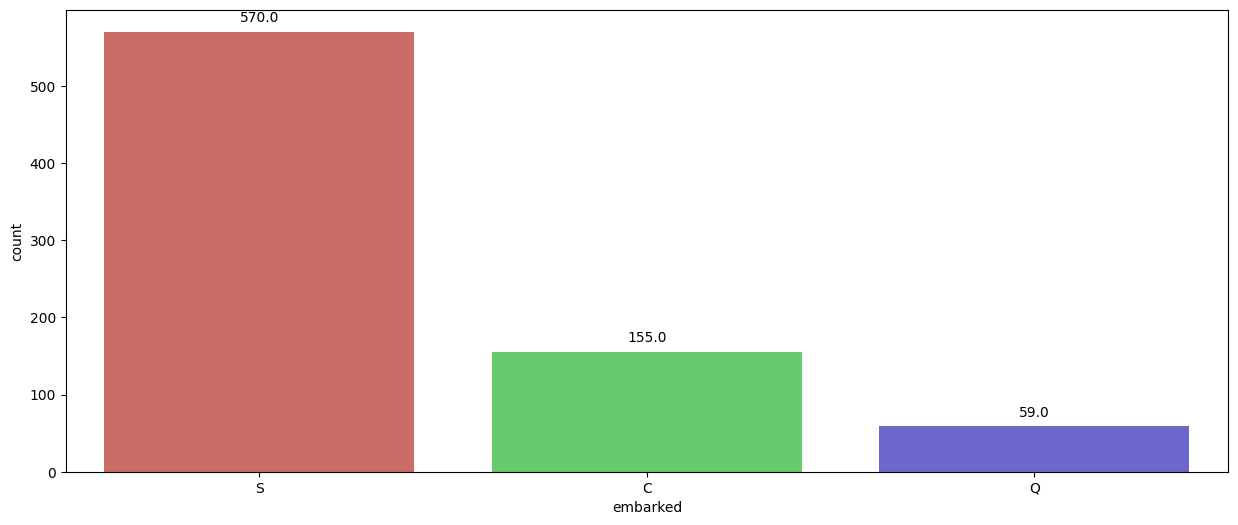

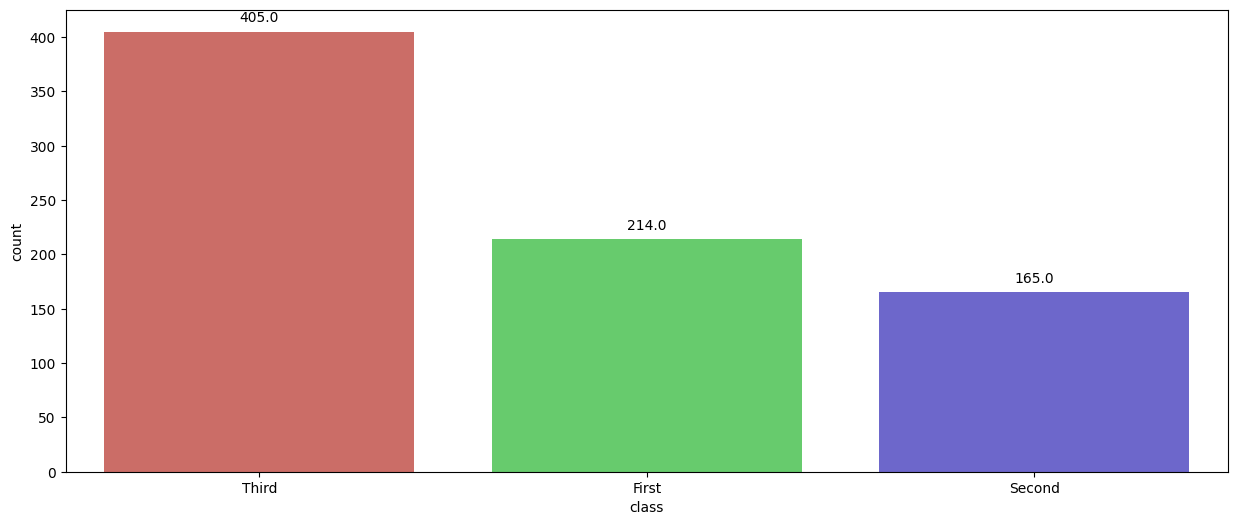

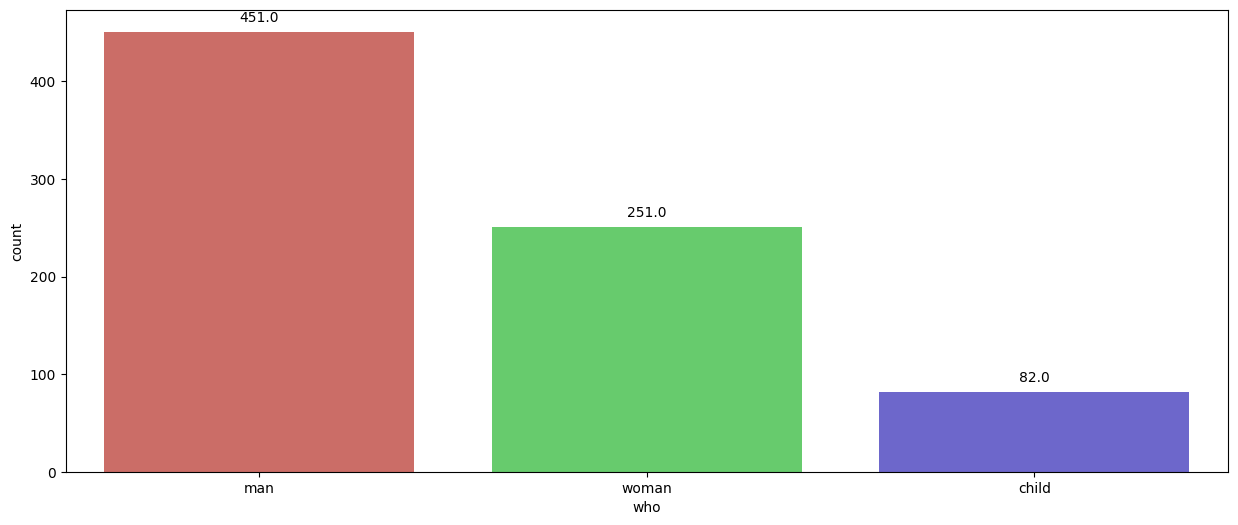

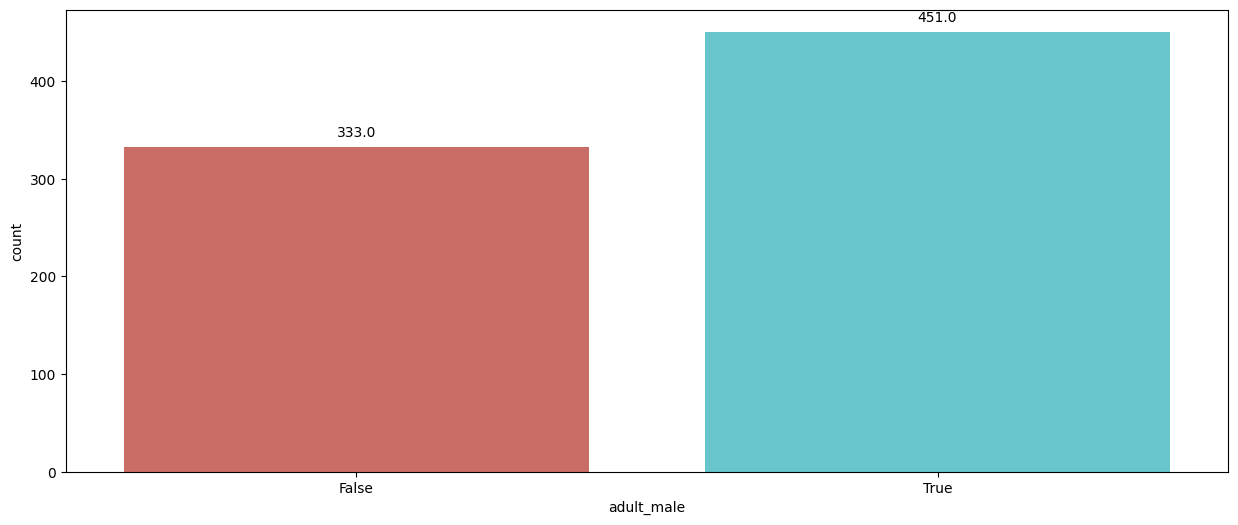

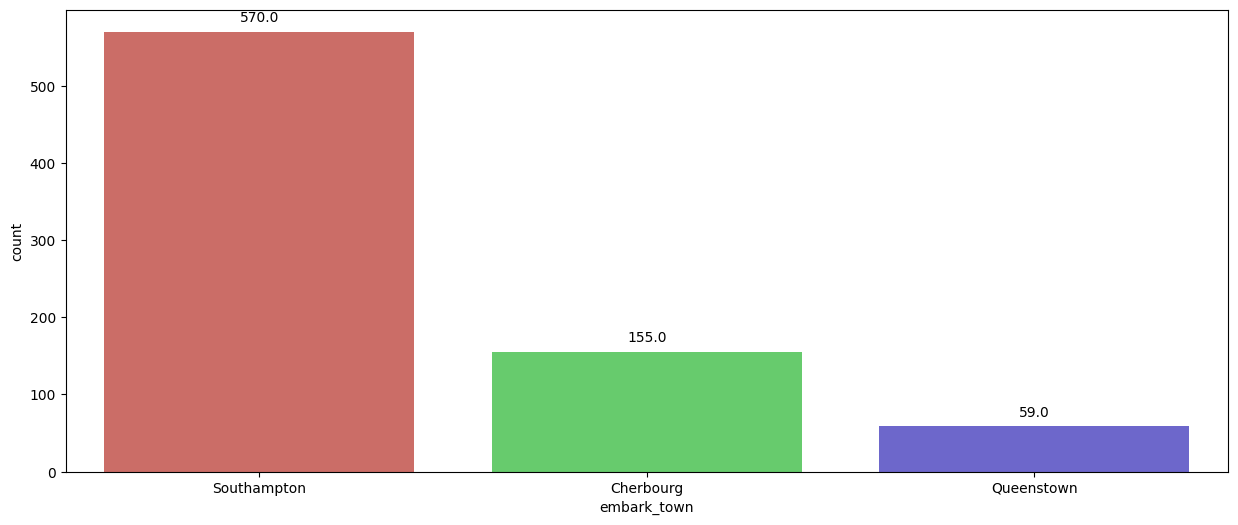

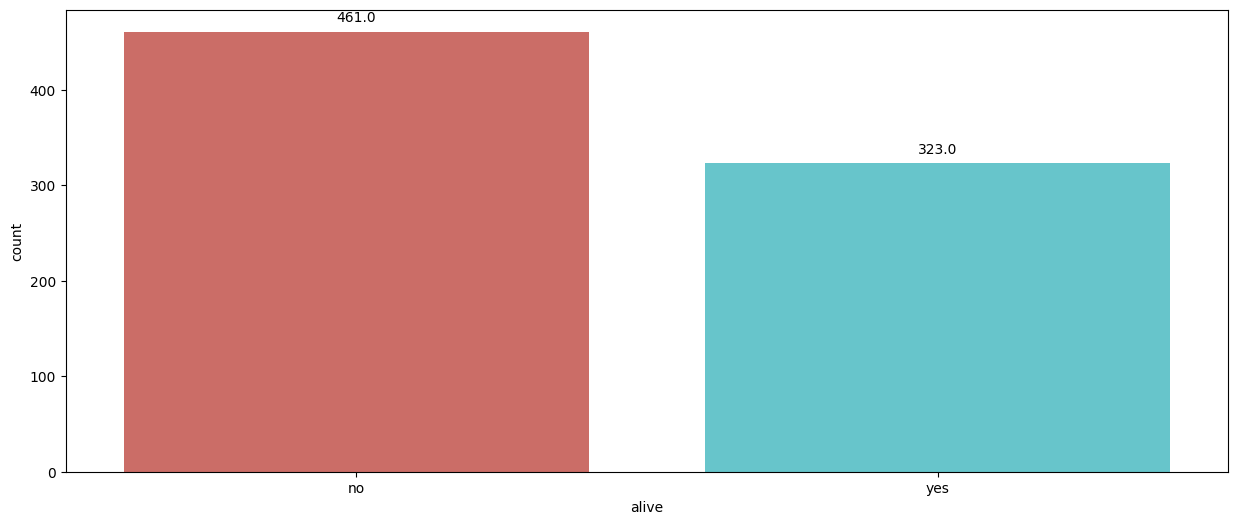

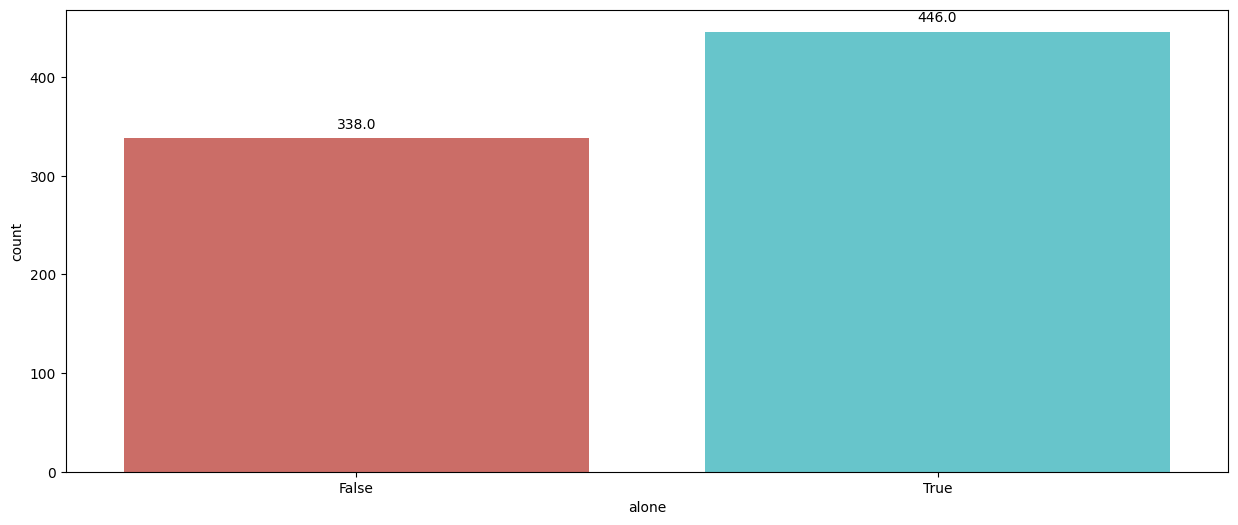

In [28]:
for i in categorical:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
    plt.show()

In [29]:
import plotly.express as px  

for i in discrete:  
    counts = df[i].value_counts().reset_index()  
    counts.columns = [i, 'count']  
    fig = px.pie(counts, values='count', names=i, title=f'Distribution of {i}')  
    fig.show()

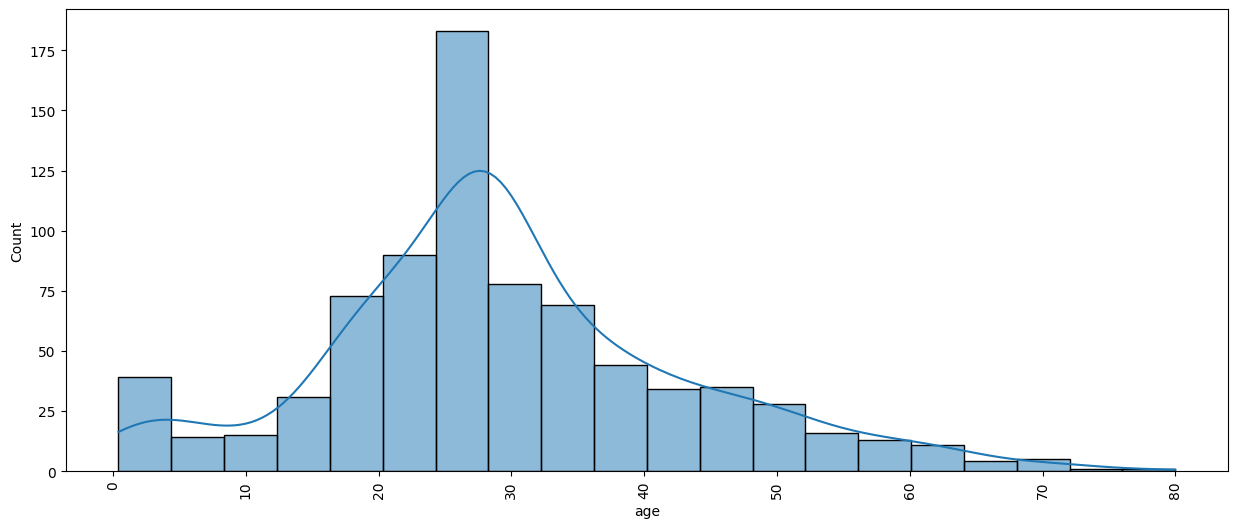

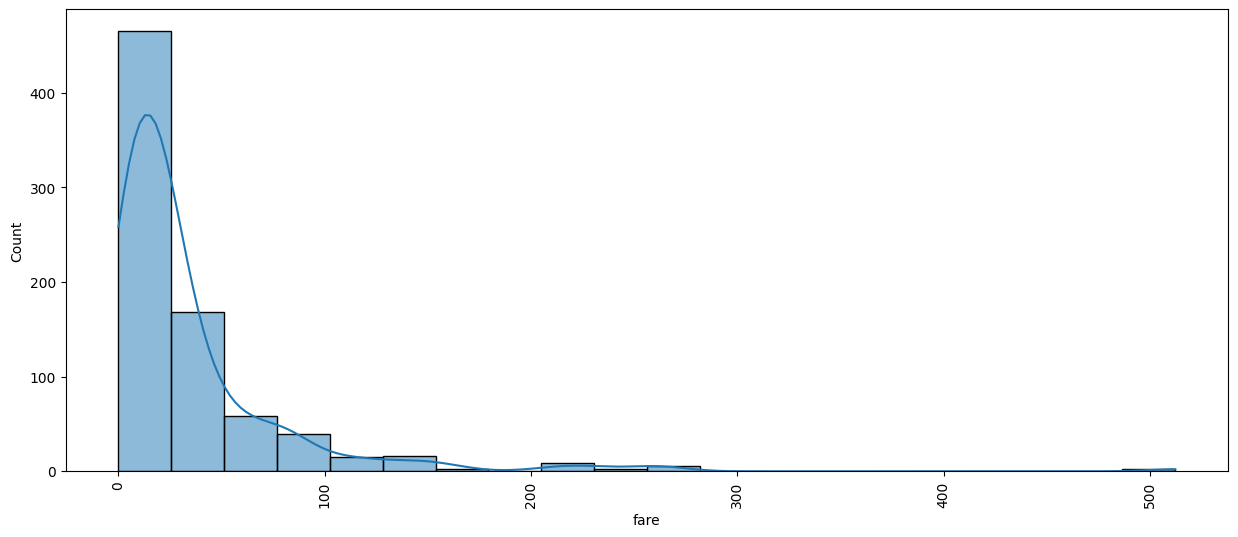

In [30]:
for i in continuous:
    plt.figure(figsize=(15,6))
    sns.histplot(df[i], bins = 20, kde = True, palette='hls')
    plt.xticks(rotation = 90)
    plt.show()

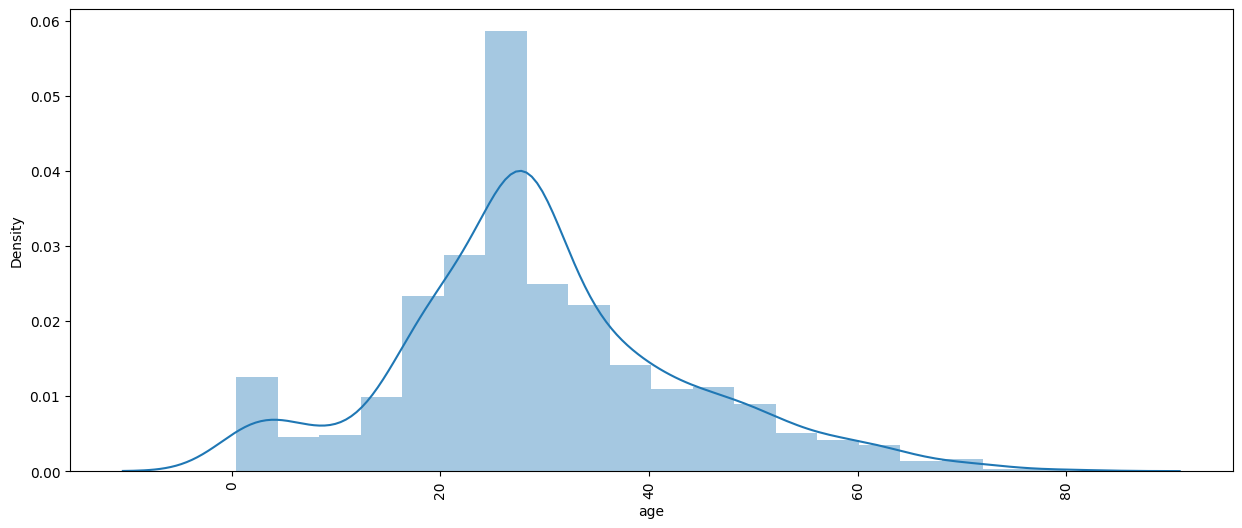

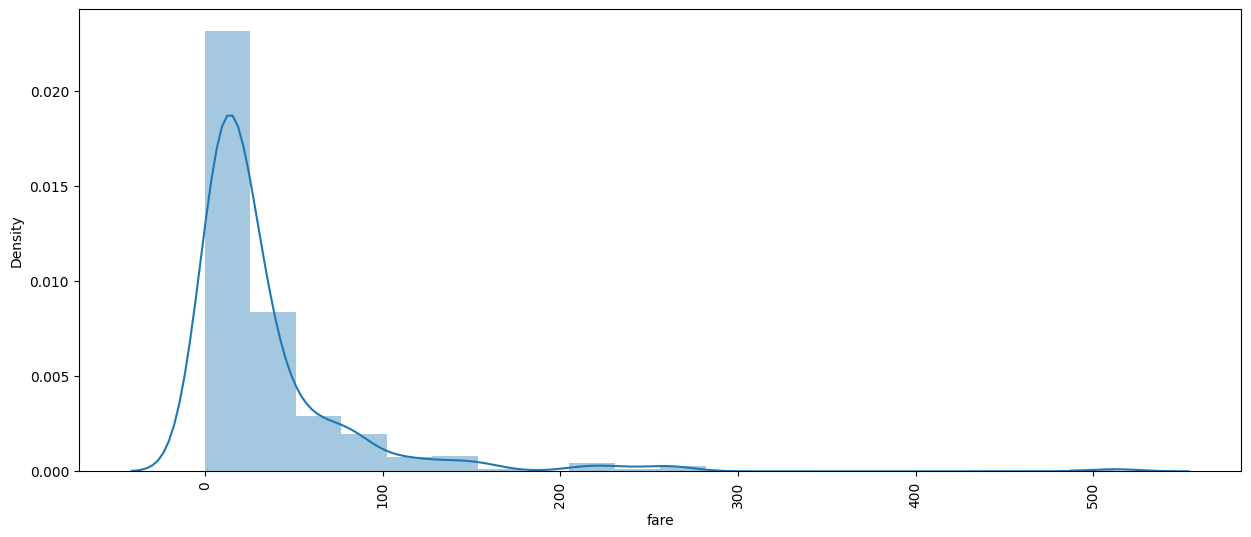

In [31]:
for i in continuous:
    plt.figure(figsize=(15,6))
    sns.distplot(df[i], bins = 20, kde = True)
    plt.xticks(rotation = 90)
    plt.show()

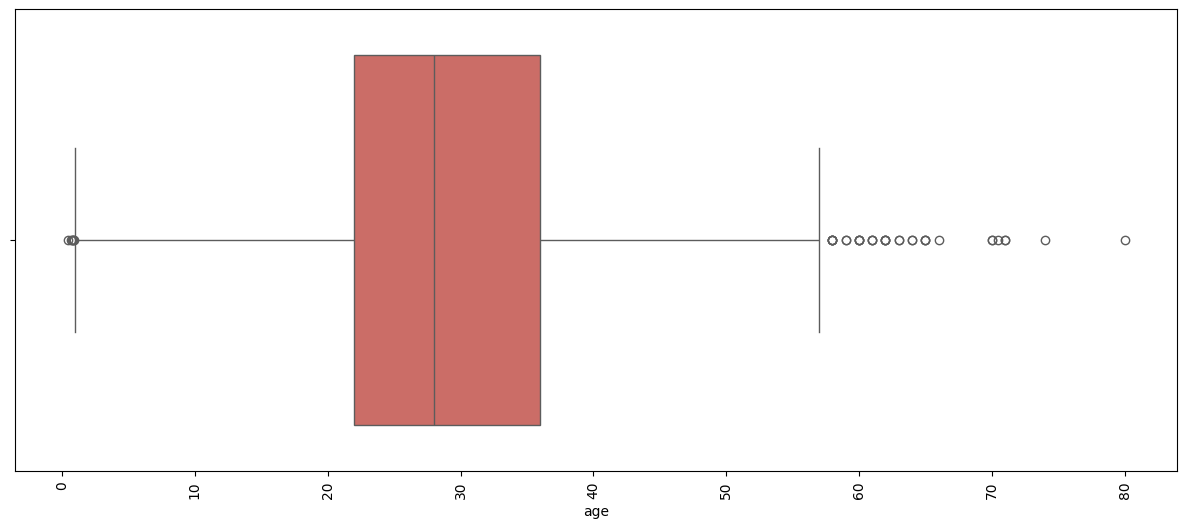

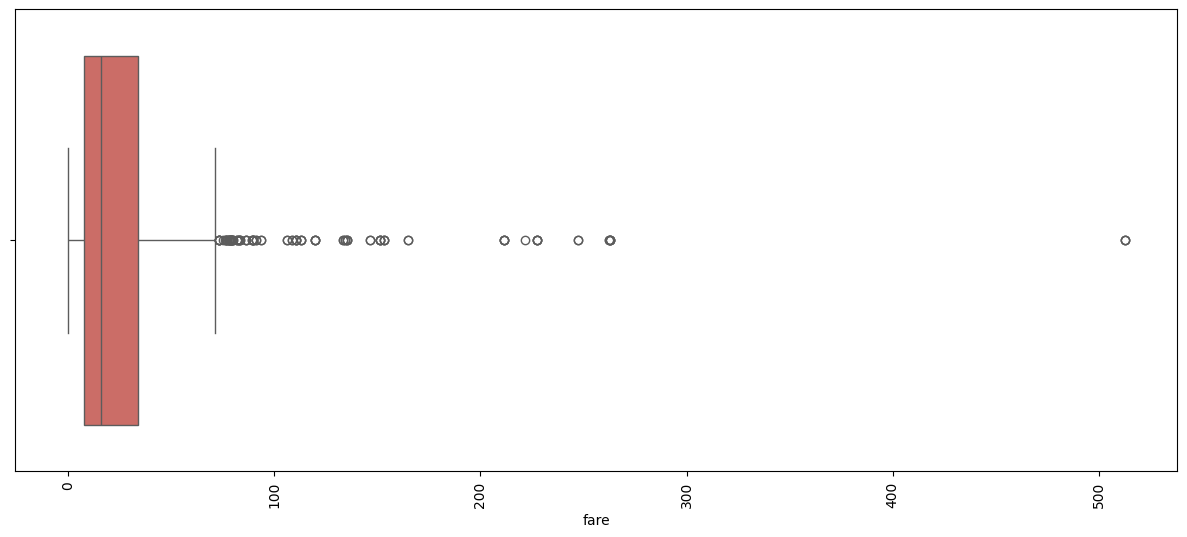

In [32]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.boxplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

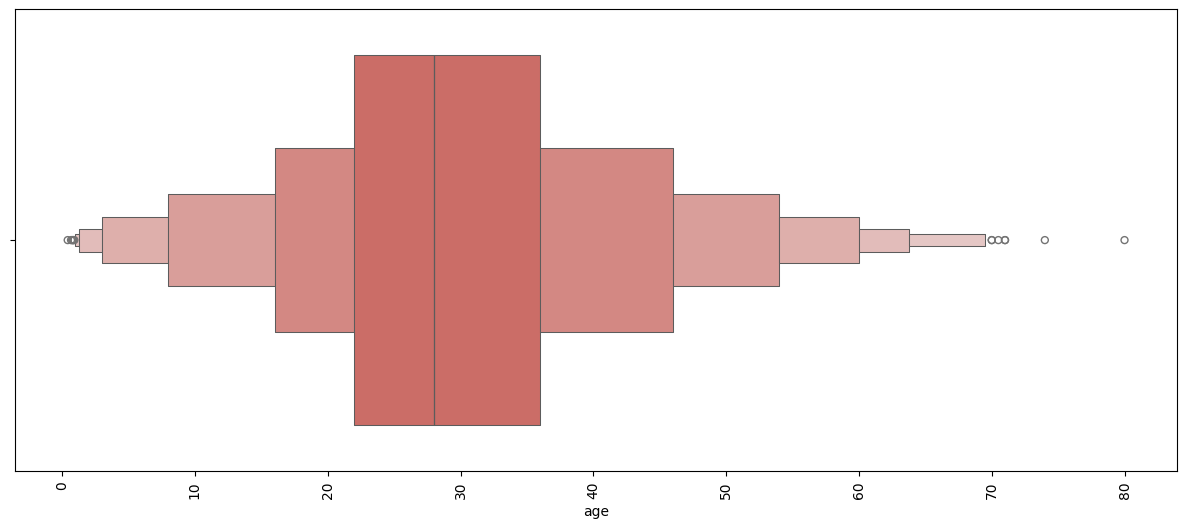

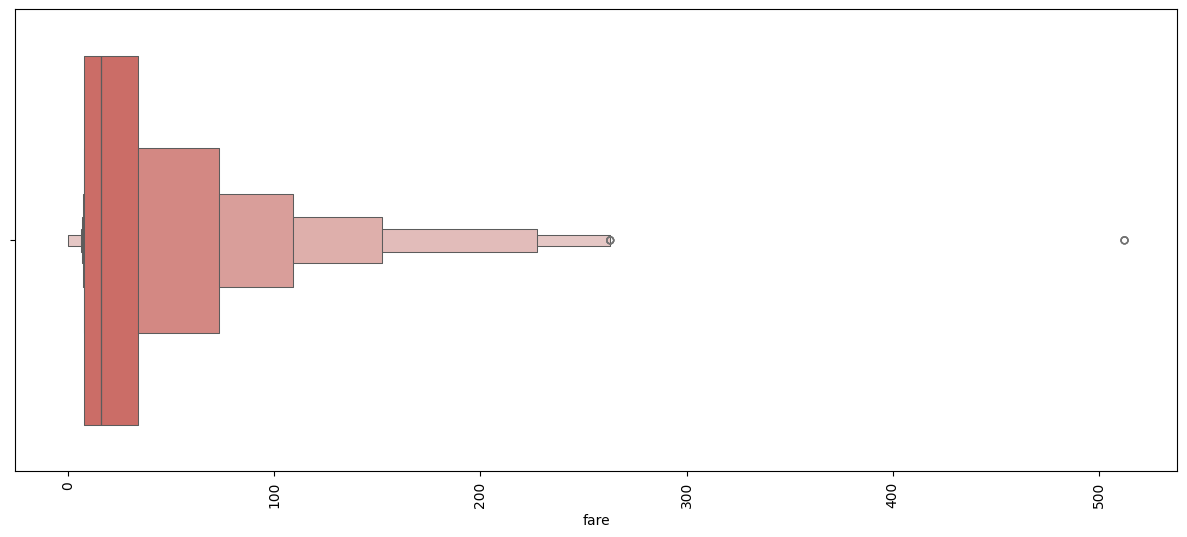

In [33]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.boxenplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

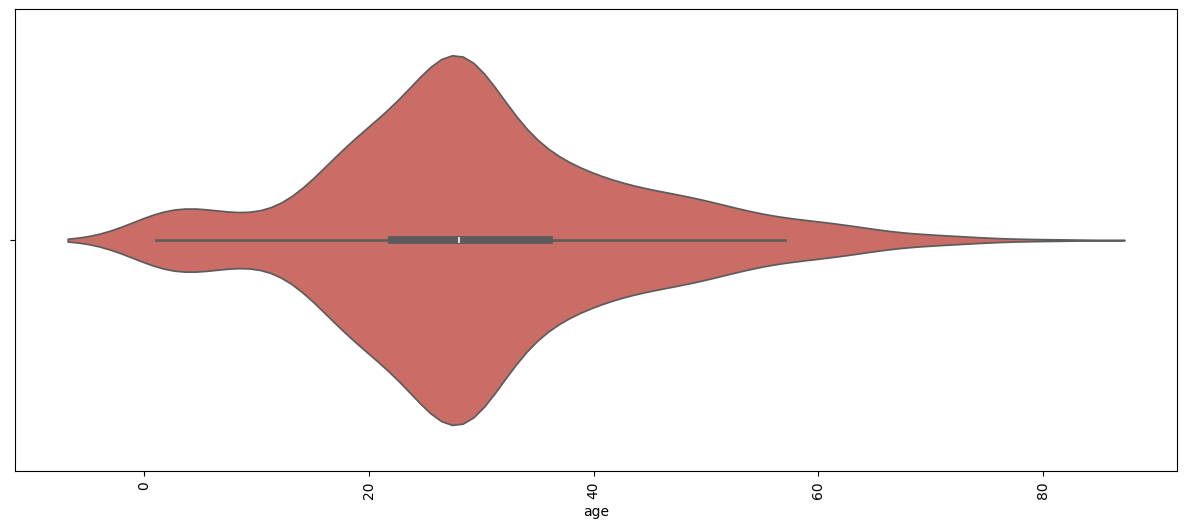

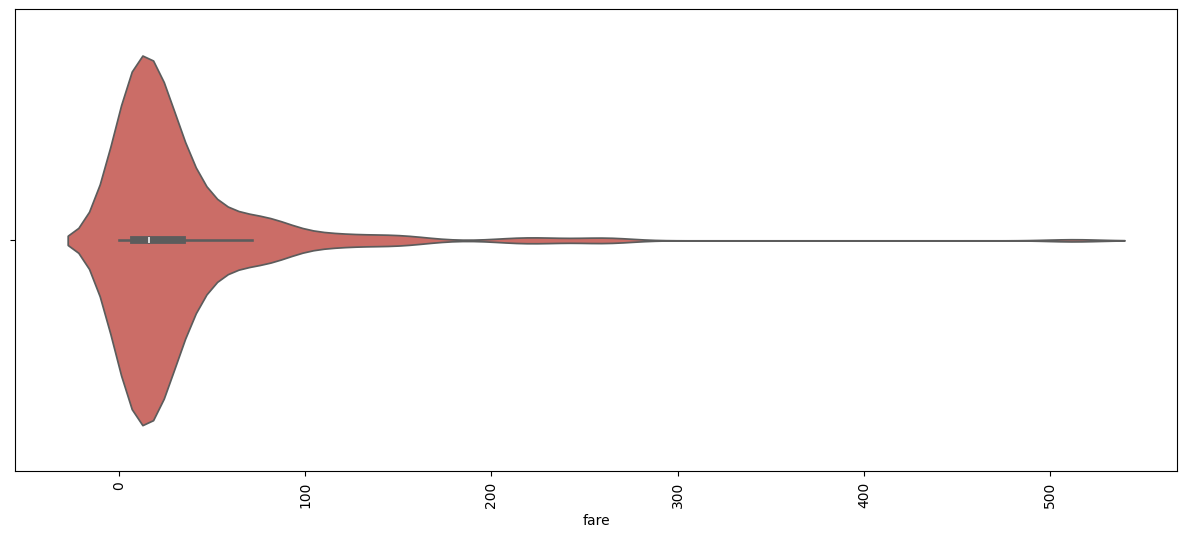

In [34]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.violinplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

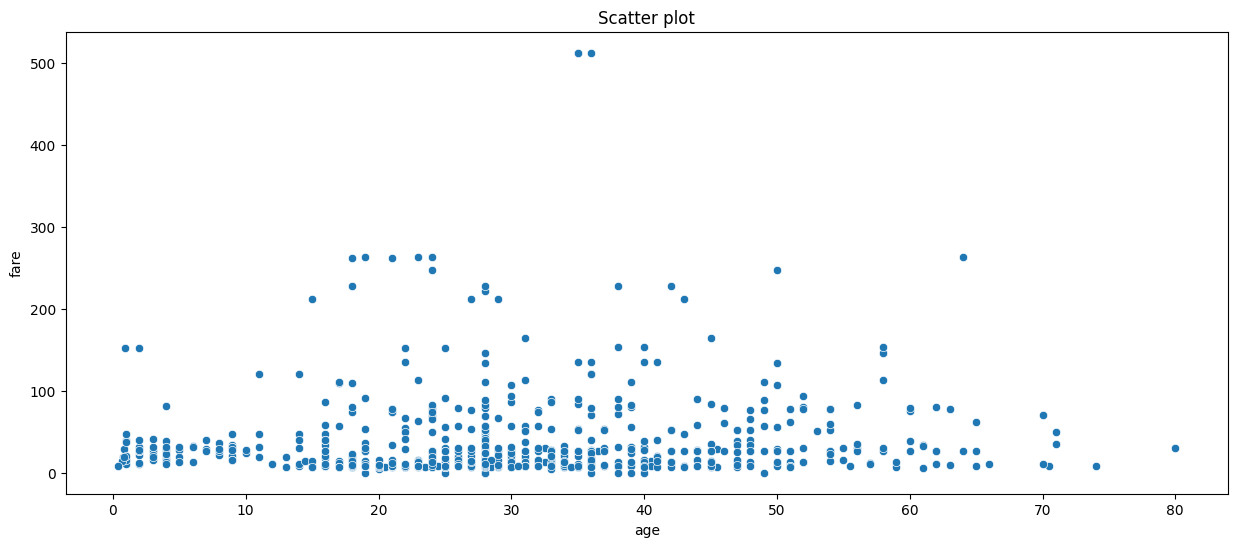

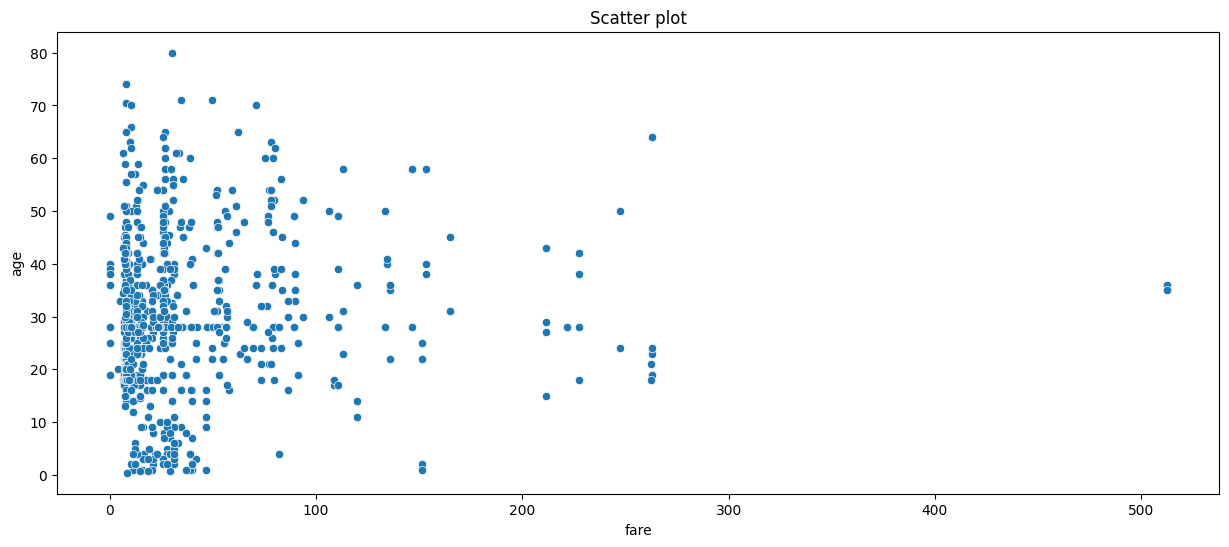

In [35]:
for i in continuous:
    for j in continuous:
        if i !=j:
            plt.figure(figsize=(15, 6))
            sns.scatterplot(x=i, y=j, data=df, palette='hls')
            plt.title(f'Scatter plot')
            plt.show()

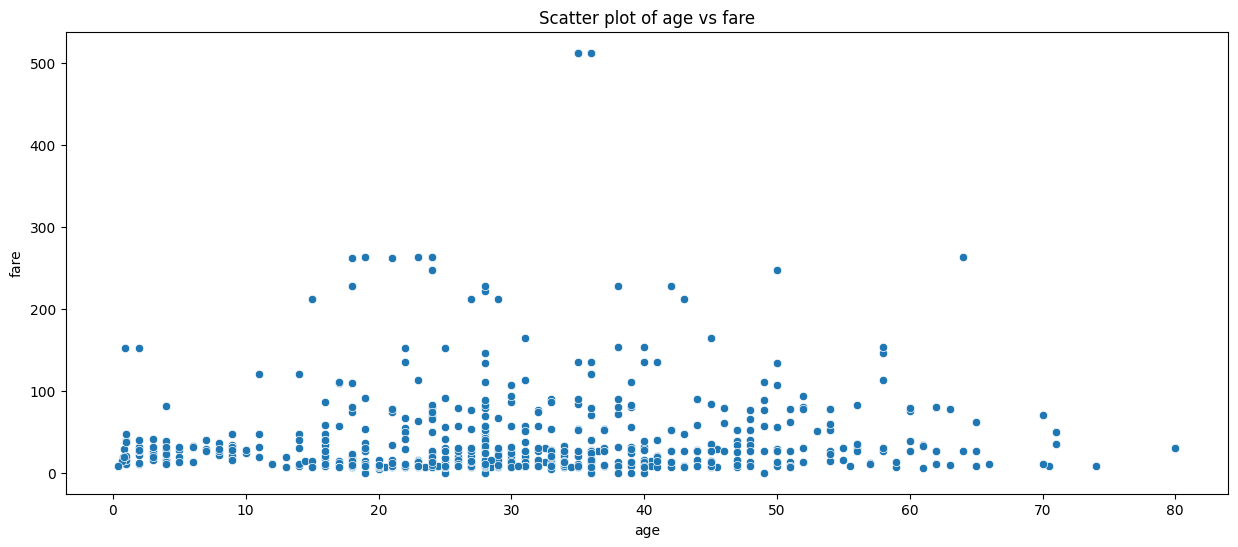

In [36]:
for i in range(len(continuous)):
    for j in range(i + 1, len(continuous)):
        plt.figure(figsize=(15, 6))
        sns.scatterplot(x=continuous[i], y=continuous[j], data=df, palette='hls')
        plt.title(f'Scatter plot of {continuous[i]} vs {continuous[j]}')
        plt.show()

In [37]:
df=df.drop(['class','adult_male','embark_town','who','alive','alone'],axis=1)

In [38]:
df

,survived,pclass,gender,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [39]:
df

,survived,pclass,gender,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


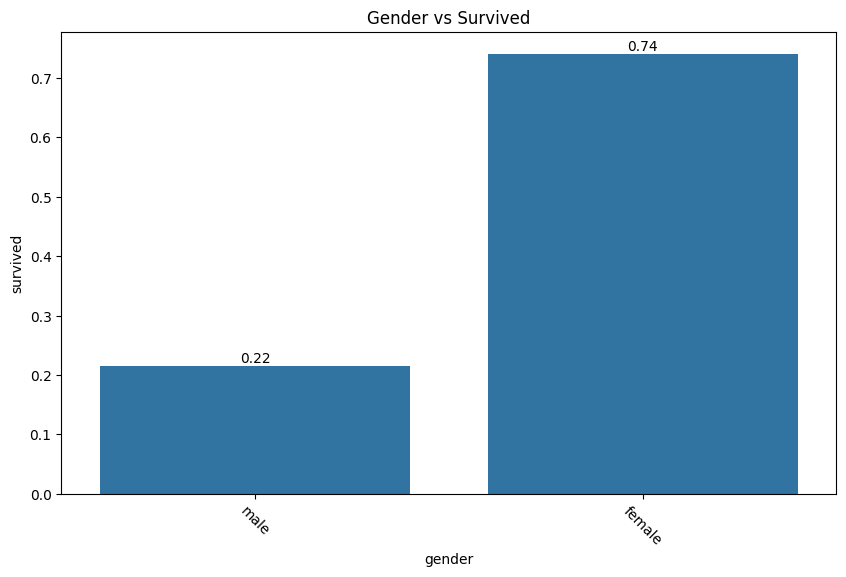

In [40]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='survived', ci=None)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs Survived')
plt.xticks(rotation=-45)
plt.show()

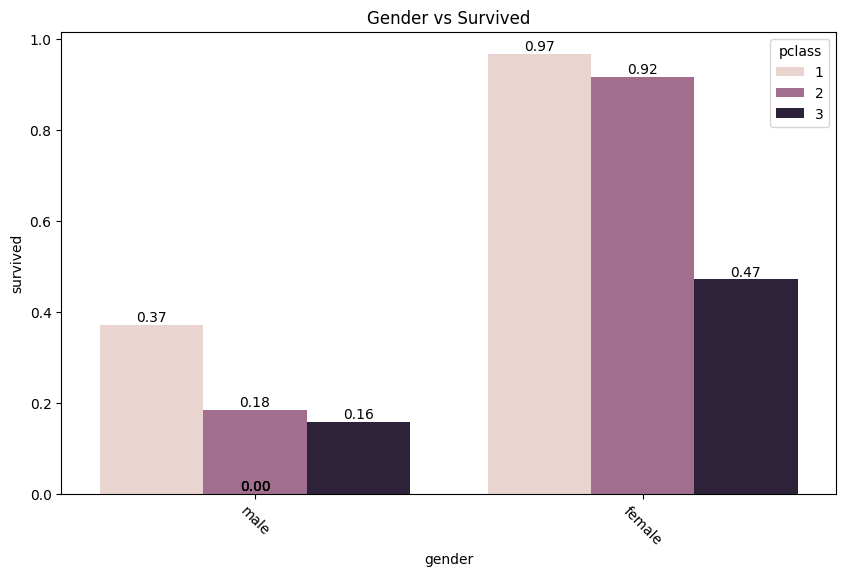

In [41]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='survived',hue='pclass', ci=None)


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs Survived')
plt.xticks(rotation=-45)
plt.show()

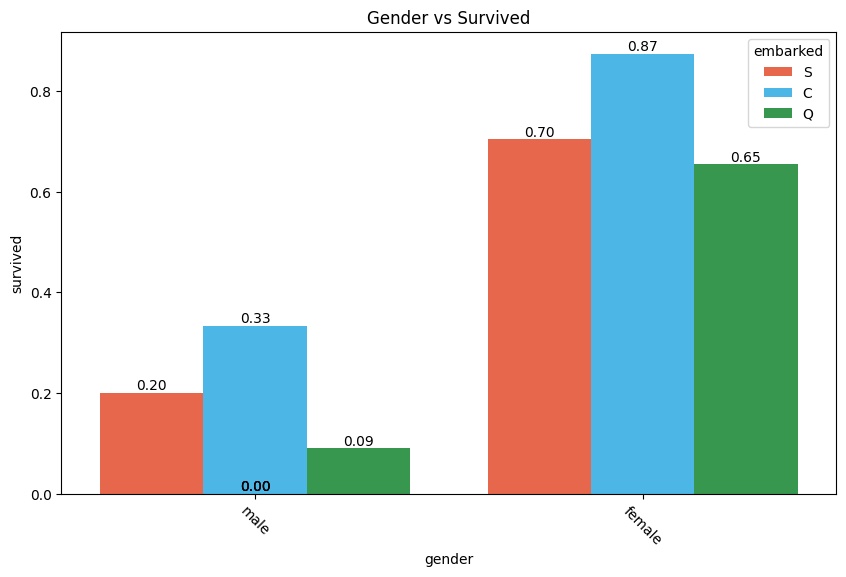

In [42]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='survived',hue='embarked', ci=None,palette=["#FF5733", "#33C1FF", "#28A745"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs Survived')
plt.xticks(rotation=-45)
plt.show()

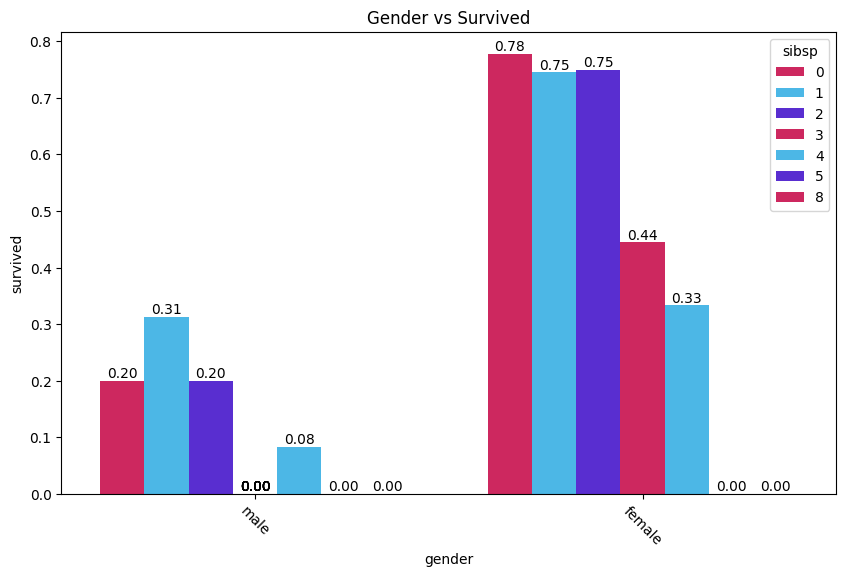

In [43]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='survived',hue='sibsp', ci=None,palette=["#E90C56", "#33C1FF", "#4C13EB"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs Survived')
plt.xticks(rotation=-45)
plt.show()

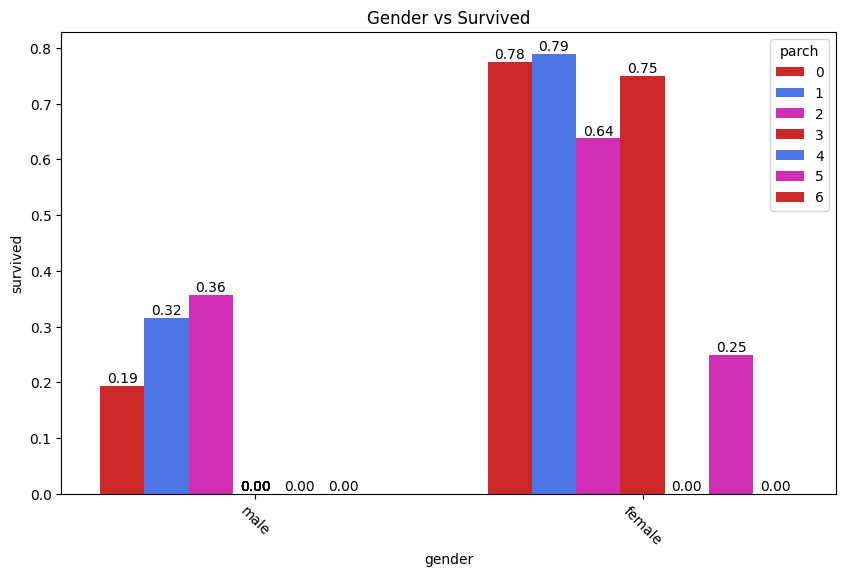

In [44]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='survived',hue='parch', ci=None,palette=["#E90C0C", "#3369FF", "#EB13C7"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs Survived')
plt.xticks(rotation=-45)
plt.show()

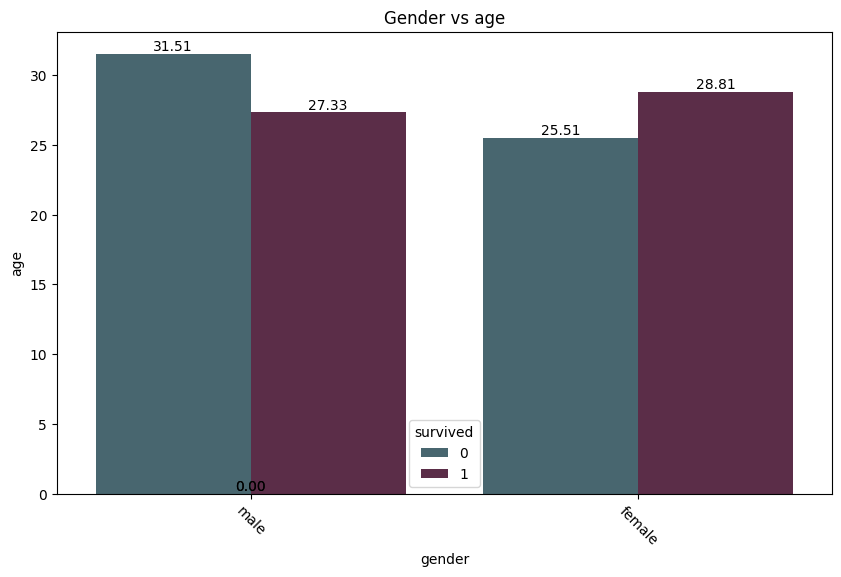

In [45]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='age',hue='survived', ci=None,palette=["#426975", "#632549", "#4C13EB"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs age')
plt.xticks(rotation=-45)
plt.show()

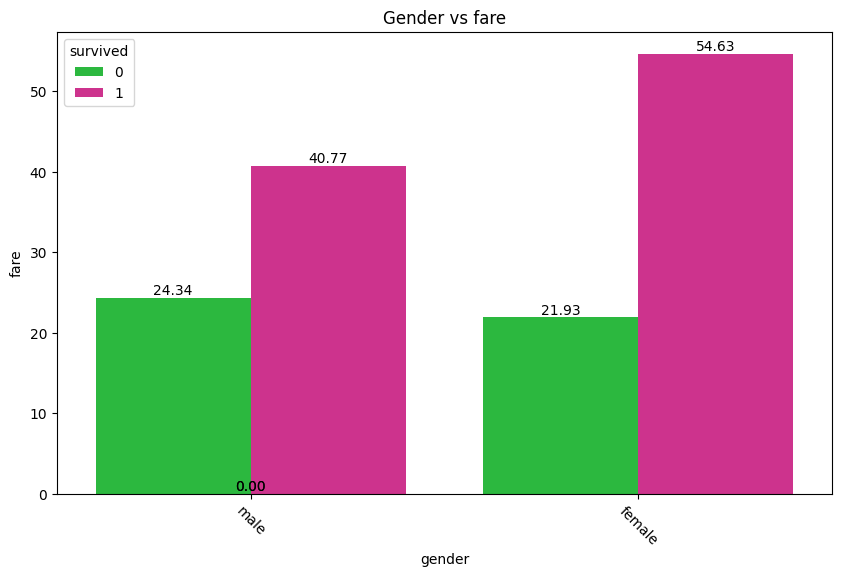

In [46]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='fare',hue='survived', ci=None,palette=["#15CF2E", "#E71991", "#4C13EB"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs fare')
plt.xticks(rotation=-45)
plt.show()

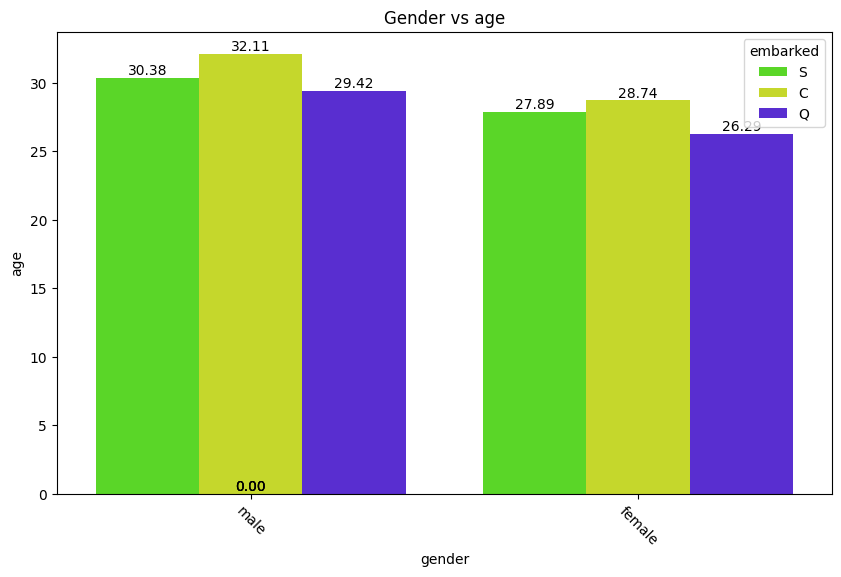

In [47]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='age',hue='embarked', ci=None,palette=["#4DF30B", "#DCF310", "#4C13EB"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs age')
plt.xticks(rotation=-45)
plt.show()

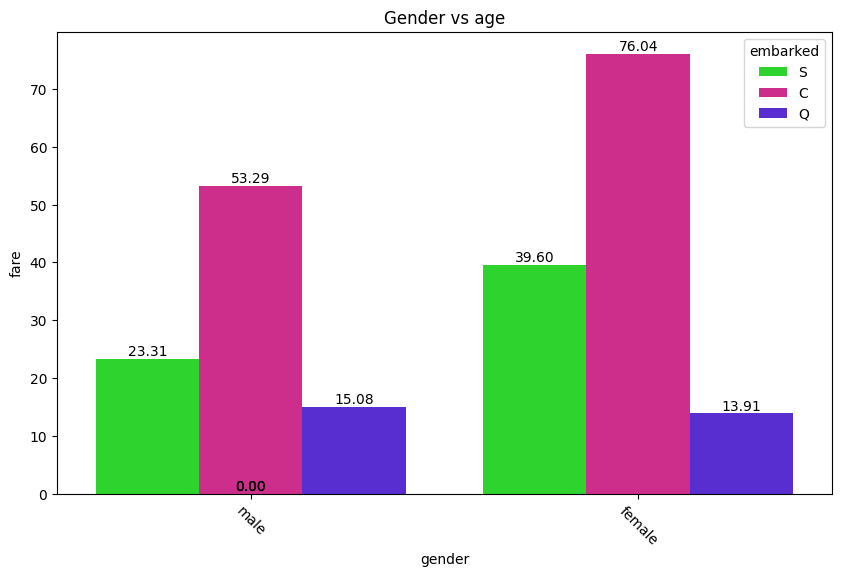

In [48]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df, x='gender', y='fare',hue='embarked', ci=None,palette=["#13EE13", "#E91390", "#4C13EB"])


for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=10, color='black')

plt.title('Gender vs age')
plt.xticks(rotation=-45)
plt.show()

In [49]:
grouped = df.groupby(['survived', 'pclass', 'gender', 'embarked'])[['age', 'sibsp', 'parch', 'fare']].mean().reset_index()

In [50]:
grouped

,survived,pclass,gender,embarked,age,sibsp,parch,fare
0,0,1,female,C,50.000000,0.000000,0.000000,28.712500
1,0,1,female,S,13.500000,1.000000,2.000000,151.550000
2,0,1,male,C,40.541667,0.166667,0.375000,83.060758
3,0,1,male,Q,44.000000,2.000000,0.000000,90.000000
4,0,1,male,S,41.617647,0.294118,0.215686,53.563316
5,0,2,female,S,36.000000,0.500000,0.166667,18.250000
6,0,2,male,C,29.312500,0.625000,0.375000,25.418225
7,0,2,male,Q,57.000000,0.000000,0.000000,12.350000
8,0,2,male,S,34.234848,0.333333,0.151515,21.337879
9,0,3,female,C,23.437500,0.500000,0.625000,14.653125


In [51]:
pivot = pd.pivot_table(
    df,
    values=['age', 'sibsp', 'parch', 'fare'],
    index=['survived', 'pclass', 'gender'],
    columns=['embarked'],
    aggfunc='mean'
)

In [52]:
pivot

age                              fare  \
embarked                        C          Q          S           C   
survived pclass gender                                                
0        1      female  50.000000        NaN  13.500000   28.712500   
                male    40.541667  44.000000  41.617647   83.060758   
         2      female        NaN        NaN  36.000000         NaN   
                male    29.312500  57.000000  34.234848   25.418225   
         3      female  23.437500  28.055556  24.120000   14.653125   
                male    27.666667  28.035714  27.434066    9.253133   
1        1      female  35.024390  33.000000  33.833333  118.890751   
                male    35.941176        NaN  34.961429  112.197806   
         2      female  19.142857  29.000000  28.732759   25.268457   
                male    14.500000        NaN  17.822000   25.433350   
         3      female  16.625000  24.285714  22.718750   14.392857   
                male    20.602222  28.333333  23.125000   11.012511   

                                                  parch                      \
embarked                        Q           S         C         Q         S   
survived pclass gender                                                        
0        1      female        NaN  151.550000  0.000000       NaN  2.000000   
                male    90.000000   53.563316  0.375000  0.000000  0.215686   
         2      female        NaN   18.250000       NaN       NaN  0.166667   
                male    12.350000   21.337879  0.375000  0.000000  0.151515   
         3      female  10.904633   20.204252  0.625000  0.888889  1.200000   
                male    12.733779   12.932597  0.083333  0.178571  0.280220   
1        1      female  90.000000   96.045660  0.317073  0.000000  0.541667   
                male          NaN   51.832739  0.294118       NaN  0.321429   
         2      female  12.350000   22.571552  0.571429  0.000000  0.706897   
                male          NaN   20.516667  1.000000       NaN  0.600000   
         3      female  10.625600   13.080338  0.928571  0.000000  0.687500   
                male    12.916667   14.567053  0.333333  0.000000  0.312500   

                           sibsp                      
embarked                       C         Q         S  
survived pclass gender                                
0        1      female  0.000000       NaN  1.000000  
                male    0.166667  2.000000  0.294118  
         2      female       NaN       NaN  0.500000  
                male    0.625000  0.000000  0.333333  
         3      female  0.500000  0.111111  1.320000  
                male    0.250000  0.714286  0.576923  
1        1      female  0.536585  1.000000  0.562500  
                male    0.352941       NaN  0.392857  
         2      female  0.714286  0.000000  0.482759  
                male    0.000000       NaN  0.600000  
         3      female  0.500000  0.285714  0.625000  
                male    0.333333  0.666667  0.312500

In [53]:
df_dummies = pd.get_dummies(df,columns=['gender','embarked'], drop_first=True)

In [54]:
df_dummies

,survived,pclass,age,sibsp,parch,fare,gender_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
885,0,3,39.0,0,5,29.1250,False,True,False
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,28.0,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from imblearn.over_sampling import RandomOverSampler

In [56]:
scaler=MinMaxScaler()
df_dummies[['age','fare']] = scaler.fit_transform(df_dummies[['age','fare']])

In [57]:
df

,survived,pclass,gender,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [58]:
df_dummies['survived'].value_counts()

survived
0    461
1    323
Name: count, dtype: int64

In [59]:
X = df_dummies.drop('survived', axis=1)  # df_final has gender & embarked encoded as numbers
y = df_dummies['survived']

In [60]:
# X = df_final.drop('survived', axis=1)
# y = df_final['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#  stratify is used to 
print("Before Oversampling:", y_train.value_counts())

Before Oversampling: survived
0    369
1    258
Name: count, dtype: int64


In [61]:

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("After Oversampling:\n", y_train_res.value_counts())

After Oversampling:
 survived
1    369
0    369
Name: count, dtype: int64


In [62]:
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
log_reg.fit(X_train_res,y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
y_pred = log_reg.predict(X_test)

In [65]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))


Accuracy: 0.802547770700637

Confusion Matrix:
 [[72 20]
 [11 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82        92
           1       0.73      0.83      0.78        65

    accuracy                           0.80       157
   macro avg       0.80      0.81      0.80       157
weighted avg       0.81      0.80      0.80       157

